# **Olivetti Facial Image Classification**

## **Decision Tree Approach with LDA Feature Reduction**

In this section, we'll utilize decision trees to classify the Olivetti faces dataset, leveraging Linear Discriminant Analysis (LDA, Fisher 1995) for dimensionality reduction to improve the classifier's performance. This method combines the feature extraction capabilities of LDA with the simple decision-making process of decision trees.

The dataset preparation and initial steps remain the same, hosted on Google Colab's Jupyter Notebook environment. You can directly edit this notebook online - make your own copy by going to `File` > `Save a copy in Drive` in the menu bar.

But first, we will train a basic decision tree classifier on the raw data (features are individual pixels) to demonstrate why we need feature extraction using LDA:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Fetching and preparing dataset
dataset = fetch_olivetti_faces(shuffle=True)
X = dataset.data
y = dataset.target

# Splitting dataset into training and testing
X_train, X_test = X[:300], X[300:]
y_train, y_test = y[:300], y[300:]

# Creating and training the decision tree classifier
tree_clf = DecisionTreeClassifier(max_depth=10)
tree_clf.fit(X_train, y_train)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

# Define Function to plot faces and predictions
def plot_predictions(images, labels, predictions):
    plt.figure(figsize=(10, 5))
    for i, (img, label, pred) in enumerate(zip(images[:10], labels[:10], predictions[:10])):
        plt.subplot(2, 5, i + 1)
        plt.imshow(img.reshape(64, 64), cmap=plt.cm.gray)
        plt.title(f"Label: {label}\nPred: {pred}")
        plt.axis('off')
    plt.tight_layout()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Shape of X_train: (300, 4096)
Shape of X_test: (100, 4096)


Once the classifier is trained, we can use it to predict face labels on the test dataset. We will evaluate the classification performance by calculating the accuracy and visualizing the results:

Classification accuracy: 16.00%


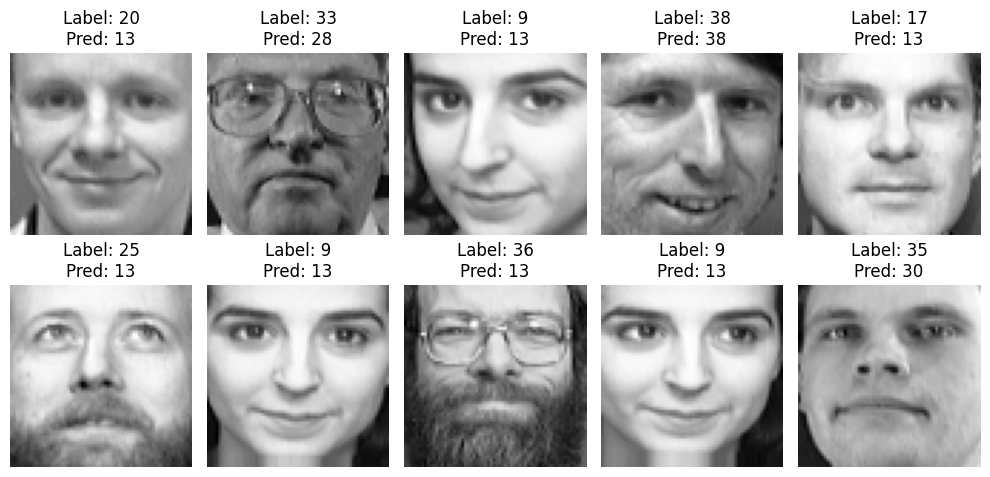

In [ ]:
# Classification accuracy on the test dataset
accuracy = tree_clf.score(X_test, y_test)
print(f"Classification accuracy: {accuracy * 100:.2f}%")

# Predicting and plotting
predictions = tree_clf.predict(X_test)
plot_predictions(X_test, y_test, predictions)


### **Discussion and Exercises**
Discuss the classification accuracy observed. Is it adequate? What are the implications of misclassifications in this scenario? How might we improve the accuracy using decision trees, such as by adjusting the depth or using ensemble methods like Random Forests?

**Exercise**: Experiment with different settings for the max_depth parameter of the Decision Tree. Analyze how these changes affect the model's performance and overfitting. What balance can you achieve between model complexity and generalization?

## **LDA Feature Reduction**

Now we apply LDA for dimensionality reduction to improve the classifier's performance, combining the feature extraction capabilities of LDA with the simple decision-making process of decision trees:

In [ ]:
# Reducing dimensionality with LDA
lda = LinearDiscriminantAnalysis(n_components=5)
X_reduced = lda.fit_transform(X, y)

# Splitting dataset into training and testing
X_train, X_test = X_reduced[:300], X_reduced[300:]
y_train, y_test = y[:300], y[300:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

# Creating and training the decision tree classifier
tree_clf = DecisionTreeClassifier(max_depth=10)
tree_clf.fit(X_train, y_train)
print(X_train.shape)

Shape of X_train: (300, 5)
Shape of X_test: (100, 5)
(300, 5)


Classification accuracy: 52.00%


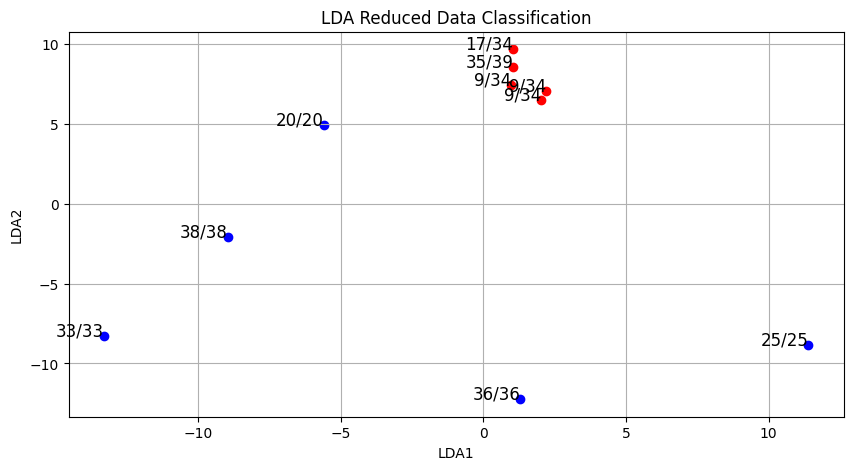

In [ ]:
# Classification accuracy on the test dataset
accuracy = tree_clf.score(X_test, y_test)
print(f"Classification accuracy: {accuracy * 100:.2f}%")

# Function to plot reduced dimensionality data and predictions
def plot_lda_predictions(lda_data, labels, predictions):
    plt.figure(figsize=(10, 5))
    for i, (data_point, label, pred) in enumerate(zip(lda_data[:10], labels[:10], predictions[:10])):
        plt.scatter(data_point[0], data_point[1], c='blue' if label == pred else 'red')
        plt.text(data_point[0], data_point[1], f"{label}/{pred}", fontsize=12, ha='right')
    plt.xlabel('LDA1')
    plt.ylabel('LDA2')
    plt.title('LDA Reduced Data Classification')
    plt.grid(True)

# Predicting and plotting
predictions = tree_clf.predict(X_test)
plot_lda_predictions(X_test, y_test, predictions)


### **Discussion and Exercises**
Evaluate the performance of the decision tree after applying LDA. How does dimensionality reduction impact the classification accuracy compared to using raw pixel data? What are some potential downsides of this method in terms of model interpretability and complexity?

**Exercise**: Explore the effects of varying the max_depth parameter of the Decision Tree. Additionally, consider using ensemble techniques such as Random Forests to see if performance can be enhanced further. Experiment with different numbers of components in LDA to find the optimal balance for this dataset.

### **LDA Feature Extraction and Discriminant**

Build an LDA model using scikit-learn, and output the classification accuracy on the validation data (outside the training set).

In [ ]:
# Splitting dataset into training and testing
X_train, X_test = X[:300], X[300:]
y_train, y_test = y[:300], y[300:]

# Classify and determine accuracy on validation data set
clf = LinearDiscriminantAnalysis(solver="svd")
clf.fit(X_train,y_train)
print("Classification accuracy:" + str(100*clf.score(X_test,y_test))+ "%")

predictions = clf.predict(X_test)
print(predictions)
print(y_test)

Classification accuracy:97.0%
[20 33  9 38 17 25  9 36  9 35 16  6 30  4 20 27 22 14 14 18 13 35 39 26
 32 20  8 12 34 36  9  8 26 11 29  5 32 25 35  4 10 36 27 35  3  5 34 12
 29  2 18 16 15 24 20  3  3 12 18 37 28 36 14 28 37 17  7 33 33 19 24 11
 26  7 33  2 16 33 38 17 38  3 29 31  8  7  8 29 24 27 21  0 35 29 25 32
 19 11  4 17]
[20 33  9 38 17 25  9 36  9 35 16  6 30  4 20 27 22 14 14 18 13 35 39 26
 32 20  8 12 34 36  9  8 26 11 29  5 32 25 35  4 10 36 27 35  3  5 34 12
 29  2 18 16 15 24 20  3  3 12 18 37 28 36 14 28 37 17  9 33 33 19 24 11
 26  7 33  2 16 33 38 17 38  3 19 31  8  7  8 29 24 27 21  0 35 19 25 32
 19 11  4 17]


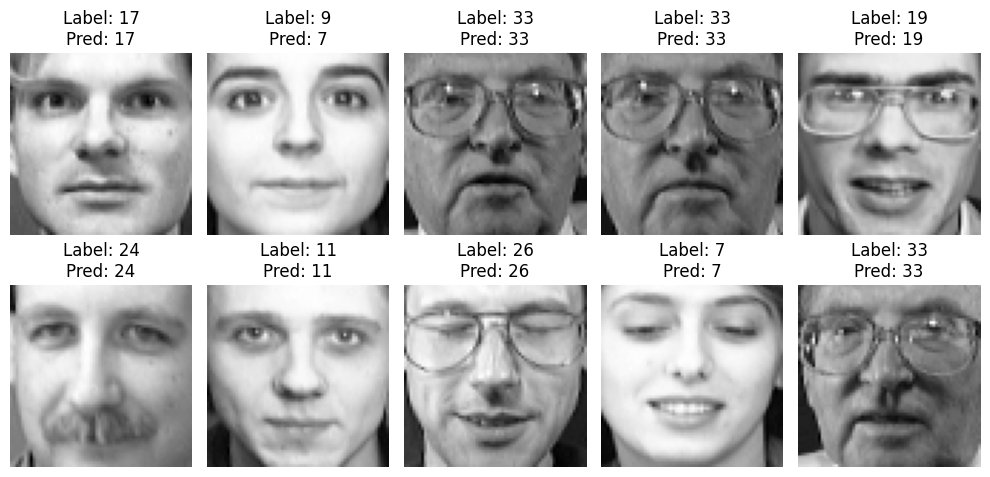

In [ ]:
plot_predictions(X_test[65:], y_test[65:], predictions[65:])

**Exercise**: Discuss the classification accuracy on the validation set. Is it higher or lower than you expected? Looking at the misclassified subjects above, explain why the classifier makes this prediction for these particular test subjects. How can the accuracy be increased?

In [ ]:
import sklearn.svm
from sklearn.svm import SVC

poly_svc = SVC(kernel='rbf',decision_function_shape='ovr')
poly_svc.fit(X_train,y_train)
print("Classification accuracy:" + str(100*poly_svc.score(X_test,y_test))+ "%")


Classification accuracy:92.0%


**Exercise**: Compare the classification accuracy of LDA to SVM-based classification with the RBF kernel. Is it higher or lower than you expected? Try changing the SVM kernel and decision_function_shape parameters. Can the accuracy be increased?

In [ ]:
# Reducing dimensionality with LDA
lda = LinearDiscriminantAnalysis(n_components=15)
X_reduced = lda.fit_transform(X, y)

# Splitting dataset into training and testing
X_train, X_test = X_reduced[:300], X_reduced[300:]
y_train, y_test = y[:300], y[300:]

# Train a basic neural network (MLP) classifier
from sklearn.neural_network import MLPClassifier

mlp_clf = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp_clf.fit(X_train, y_train)

# Classification accuracy on the test dataset
accuracy_mlp = mlp_clf.score(X_test, y_test)
print(f"MLP Classification accuracy with LDA reduced data: {accuracy_mlp * 100:.2f}%")

MLP Classification accuracy with LDA reduced data: 100.00%


In [ ]:
print(f"Number of input features: {mlp_clf.n_features_in_}")
print(f"Number of neurons per hidden layer: {mlp_clf.hidden_layer_sizes}")
print(f"Number of layers (including input and output): {mlp_clf.n_layers_}")
print(f"Activation function for the hidden layer: {mlp_clf.activation}")

Number of input features: 15
Number of neurons per hidden layer: (100,)
Number of layers (including input and output): 3
Activation function for the hidden layer: relu
